In [2]:
import torch
import os
from utilities import *
device = torch.device('cpu')
print(device)

cpu


In [3]:
# Parameters

ranges = [-1, 1]
n_train = 1000
n_test = 1000
steps = 1200
grids = [3, 5, 10, 20, 50, 100]
k=5
lr=1
dimensions = [1000, 500, 200, 100, 50, 20, 10, 5]
seeds = [0]

In [ ]:
def train_all_seeds(data):
    static_kan = {}
    dyn_kan = {}
    mlp = {}

    for seed in seeds:
        
        static_kan_results = {}
        dyn_kan_results = {}
        mlp_results = {}
        
        for d in dimensions:
            # dataset = generate_dataset(dim=d, seed=seed, data=data)
            # torch.save(dataset, f'{data}_dataset_dim{d}_seed{seed}.pt')
            dataset_path = os.path.join("datasets", f'{data}_dataset_dim{d}_seed{seed}.pt')
            if os.path.exists(dataset_path):
                dataset = torch.load(dataset_path, map_location=device)
            else:
                raise FileNotFoundError(f"Dataset file not found: {dataset_path}")
            width = [d, 1, 1]
            kan_param = (width[0] * width[1] * (grids[0] + k + 3) + width[1]) + (width[1] * width[2] * (grids[0] + k + 3) + width[2])
            # mlp_hidden_width = (kan_param - 1) // (width[0] + 2)
            mlp_hidden_width = math.ceil((11*d+13)/(d+2)) - 1
            static_kan_results[d] = train_kan(width=width, dataset=dataset, static=True, seed=seed, steps=steps,grids=grids, lr=lr)
            dyn_kan_results[d] = train_kan(width=width, dataset=dataset, static=False, seed=seed, steps=steps, grids=grids, lr=lr)
            mlp_results[d] = train_mlp(width=[d, mlp_hidden_width, 1], dataset=dataset, seed=seed, steps=steps, lr=lr)
            mlp_param = mlp_results[d]['param_counts']
            print(f"Dimension {d}: KAN params: {kan_param}, MLP params: {mlp_param}")
        
        static_kan[seed] = static_kan_results
        dyn_kan[seed] = dyn_kan_results
        mlp[seed] = mlp_results
    
    torch.save(static_kan, os.path.join("3-results", f'static_kan_{data}.pt'))
    torch.save(dyn_kan, os.path.join("3-results", f'dyn_kan_{data}.pt'))
    torch.save(mlp, os.path.join("3-results", f'mlp_{data}.pt'))
    return static_kan, dyn_kan, mlp


In [ ]:
static_kan_A, dyn_kan_A, mlp_A = train_all_seeds('A')

In [ ]:
static_kan_B, dyn_kan_B, mlp_B = train_all_seeds('B')

In [ ]:
static_kan_C, dyn_kan_C, mlp_C = train_all_seeds('C')

In [7]:
static_kan_A, dyn_kan_A, mlp_A = torch.load(os.path.join("3-results", "1200-epochs-1-seed", 'static_kan_A.pt'), weights_only=False), torch.load(os.path.join("3-results", "1200-epochs-1-seed", 'dyn_kan_A.pt'), weights_only=False), torch.load(os.path.join("3-results", "1200-epochs-1-seed", 'mlp_A.pt'), weights_only=False)
static_kan_B, dyn_kan_B, mlp_B = torch.load(os.path.join("3-results", "1200-epochs-1-seed", 'static_kan_B.pt'), weights_only=False), torch.load(os.path.join("3-results", "1200-epochs-1-seed", 'dyn_kan_B.pt'), weights_only=False), torch.load(os.path.join("3-results", "1200-epochs-1-seed", 'mlp_B.pt'), weights_only=False)
static_kan_C, dyn_kan_C, mlp_C = torch.load(os.path.join("3-results", "1200-epochs-1-seed", 'static_kan_C.pt'), weights_only=False), torch.load(os.path.join("3-results", "1200-epochs-1-seed", 'dyn_kan_C.pt'), weights_only=False), torch.load(os.path.join("3-results", "1200-epochs-1-seed", 'mlp_C.pt'), weights_only=False)

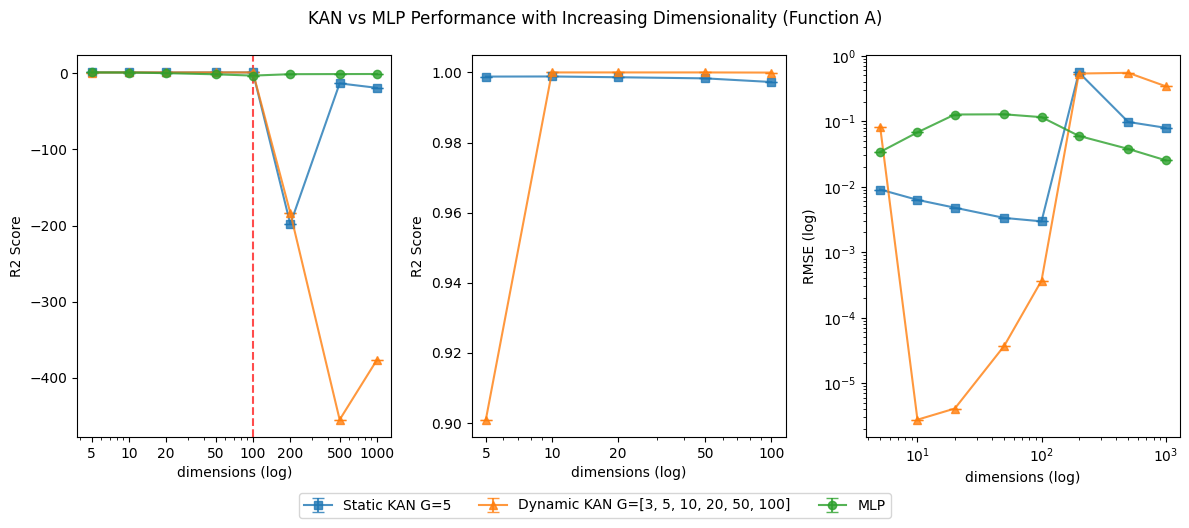

In [8]:
plot_r2s_rmses(static_kan_A, dyn_kan_A, mlp_A, dimensions, seeds, 'A')

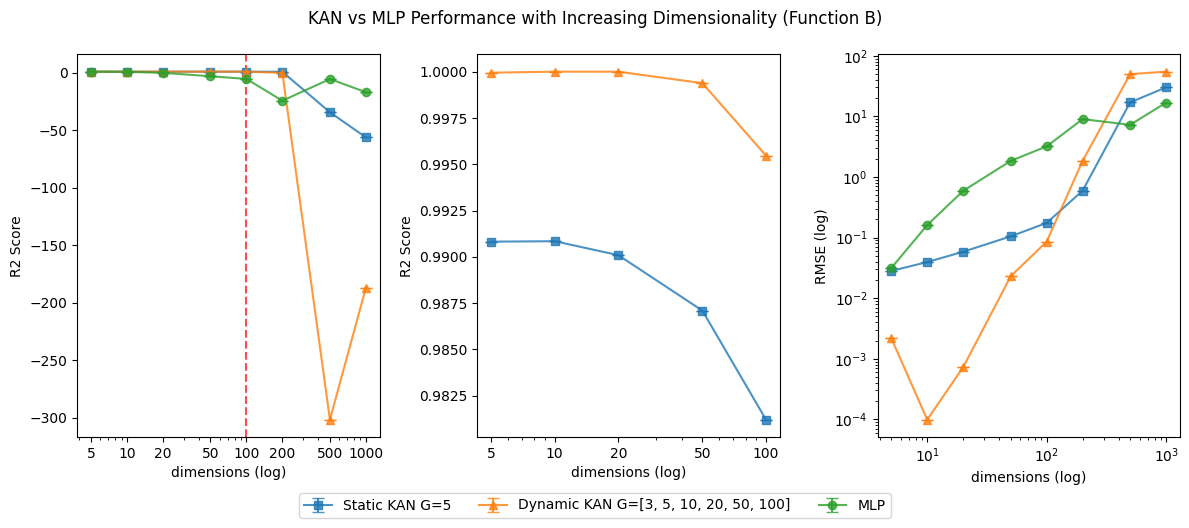

In [9]:
plot_r2s_rmses(static_kan_B, dyn_kan_B, mlp_B, dimensions, seeds, 'B')

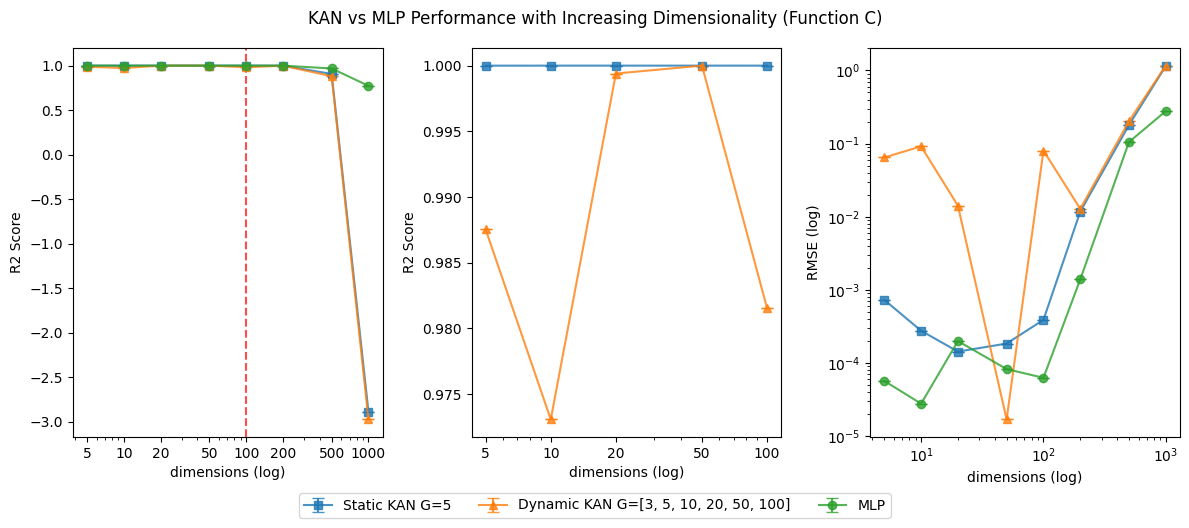

In [10]:
plot_r2s_rmses(static_kan_C, dyn_kan_C, mlp_C, dimensions, seeds, 'C')